In [3]:
# Autoencoder for Image Denoising using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Install torchsummary
!pip install torchsummary
from torchsummary import summary

In [5]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# Transform and load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.23MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.28MB/s]


In [7]:
# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

In [8]:
# Define Convolutional Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (64, 7, 7)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # (32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),   # (1, 28, 28)
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
# Initialize model, loss function and optimizer
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [10]:
# Print model summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
   ConvTranspose2d-7           [-1, 32, 14, 14]           8,224
              ReLU-8           [-1, 32, 14, 14]               0
   ConvTranspose2d-9            [-1, 1, 28, 28]             129
          Sigmoid-10            [-1, 1, 28, 28]               0
Total params: 27,169
Trainable params: 27,169
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.75
Params size (MB): 0.10
Estimated Tot

In [11]:
# Train the autoencoder
def train(model, loader, criterion, optimizer, epochs=5):
    train_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)

            optimizer.zero_grad()
            outputs = model(noisy_images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

    return train_losses

In [12]:
# Run training
train_losses = train(model, train_loader, criterion, optimizer, epochs=5)

Epoch [1/5], Loss: 0.050938
Epoch [2/5], Loss: 0.017828
Epoch [3/5], Loss: 0.016196
Epoch [4/5], Loss: 0.015422
Epoch [5/5], Loss: 0.014987


Name: Niralya J
Register Number: 212224230188


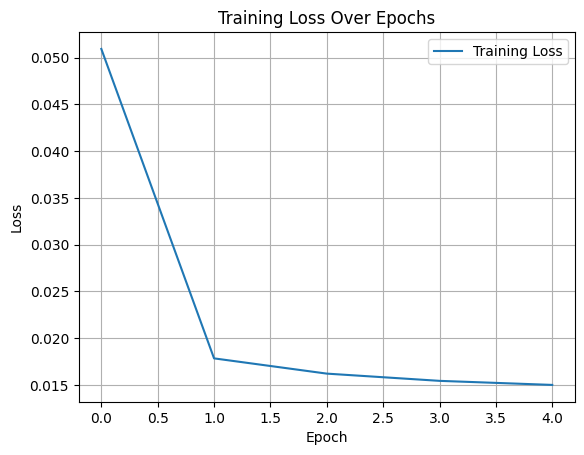

In [13]:
# Plot training loss
print('Name: Niralya J')
print('Register Number: 212224230188')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Evaluate and visualize
def visualize_denoising(model, loader, num_images=3):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)
            outputs = model(noisy_images)
            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print('Name: Niralya J')
    print('Register Number: 212224230188')
    plt.figure(figsize=(18, 6))
    for i in range(num_images):
        # Original
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title("Original")
        plt.axis("off")

        # Noisy
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        ax.set_title("Noisy")
        plt.axis("off")

        # Denoised
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.set_title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Name: Niralya J
Register Number: 212224230188


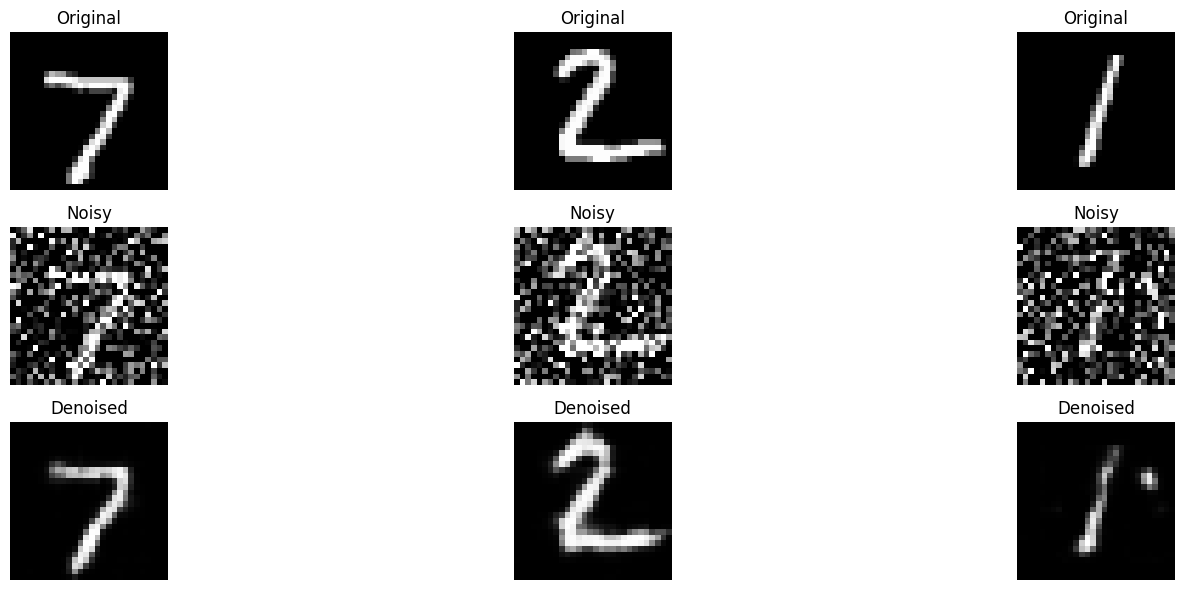

In [19]:
# Run visualization
visualize_denoising(model, test_loader)